# Unsupervised GMM clusters for matched events

This notebook tries an unsupervised approach to find **gg-like subregions** in the matched sample.

Setup:

- Training sample: `channel2 in [1, 2, 3]` only.
- Features: 12 CMS-like variables plus symmetric sum/absolute-difference features.
- `dpsi12` is **not** used for clustering. It is used only for validation.
- Algorithm: `GaussianMixture`.
- Scan: `K = 3, 4, 5, 6` clusters.
- Default working choice: `K = 4`.
- Validation: plot `dpsi12` distributions with `density=True` for every cluster and fit
  \[N(\Delta\psi_{12}) = a + b\cos(2\Delta\psi_{12})\]
  so `c2 = b/a`.

Interpretation: this does **not** prove event-by-event clean truth-level `gg`. It identifies observable clusters, then checks whether one cluster has a positive `cos(2 dpsi12)` modulation and a gg-like feature profile.


In [6]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import dump, load
from scipy.optimize import curve_fit
from sklearn.impute import SimpleImputer
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Paths

Change `CSV_PATH` if your file is somewhere else. The fallback list matches the previous notebooks.

In [7]:

CSV_PATH = Path("merged_ML.csv")

fallback_paths = [
    Path("merged_ML.csv"),
    Path("merged_ML(1).csv"),
    Path("../csv/merged_ML.csv"),
    Path("../merged_ML.csv"),
    Path("/mnt/data/merged_ML(1).csv"),
    Path("/mnt/data/merged_ML.csv"),
]

if not CSV_PATH.exists():
    for path in fallback_paths:
        if path.exists():
            CSV_PATH = path
            break

if not CSV_PATH.exists():
    raise FileNotFoundError(
        "Could not find merged_ML.csv. Set CSV_PATH to the location of your CSV."
    )

MODEL_DIR = Path("models_unsupervised_gmm_matched")
OUTPUT_DIR = Path("outputs_unsupervised_gmm_matched")
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print("Using CSV:", CSV_PATH.resolve())
print("Model directory:", MODEL_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())


Using CSV: /Users/alexmendonca/Desktop/pic2/csv/merged_ML.csv
Model directory: /Users/alexmendonca/Desktop/pic2/python/models_unsupervised_gmm_matched
Output directory: /Users/alexmendonca/Desktop/pic2/python/outputs_unsupervised_gmm_matched


## 2. Load data and keep matched events

We keep only `channel2 in [1, 2, 3]`.

`dpsi12` is kept in the dataframe for validation plots but is explicitly excluded from clustering features.

In [ ]:

df_raw = pd.read_csv(CSV_PATH)
print("Raw shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())

TARGET = "channel2"
DPSI_COL = "dpsi12"

if TARGET not in df_raw.columns:
    raise ValueError(f"Missing required target column: {TARGET}")
if DPSI_COL not in df_raw.columns:
    raise ValueError(f"Missing required validation column: {DPSI_COL}")

# Keep matched IFN categories only.
KEEP_CLASSES = [1, 2, 3]
df = df_raw[df_raw[TARGET].isin(KEEP_CLASSES)].copy()

CLASS_NAMES = {
    1: "qqbar",
    2: "qg",
    3: "gg-like",
}

print("Matched-only shape:", df.shape)
print("channel2 counts:")
display(df[TARGET].value_counts().sort_index().rename("count").to_frame())
print("channel2 fractions:")
display((100 * df[TARGET].value_counts(normalize=True).sort_index()).rename("percent").to_frame())


Raw shape: (5847342, 17)
Columns: ['Event', 'Jet', 'z1', 'z2', 'deltaR34', 'kt2', 'N_charged3', 'N_charged4', 'N_all3', 'N_all4', 'pt_weight3', 'pt_weight4', 'pt_dispersion3', 'pt_dispersion4', 'tau_time', 'channel2', 'dpsi12']
Matched-only shape: (4397983, 17)
channel2 counts:


,count
channel2,
0,4397983


channel2 fractions:


,percent
channel2,
0,100.0


## 3. Build CMS-like + symmetric clustering features

The base 12 variables are:

- `z1`, `z2`
- `deltaR34`
- `kt2`
- `N_charged3`, `N_charged4`
- `N_all3`, `N_all4`
- `pt_weight3`, `pt_weight4`
- `pt_dispersion3`, `pt_dispersion4`

The symmetric features are sum and absolute difference for the paired subjet variables.

Note: `dpsi12`, `channel2`, event IDs, and any DNN scores are not used as clustering inputs.

In [ ]:
def add_clustering_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create clustering features.

    Important:
    - Does NOT use dpsi12.
    - Does NOT use channel2 as an input.
    - Adds sum/absdiff/min/max features so the GMM can see whether BOTH subjets are gluon-like.
    """
    df = df.copy()

    # Stable transforms
    for col in ["pt_dispersion3", "pt_dispersion4"]:
        if col in df.columns:
            df[col] = np.log1p(df[col].clip(lower=0))

    if "kt2" in df.columns:
        df["kt2"] = np.log1p(df["kt2"].clip(lower=0))

    if "deltaR34" in df.columns:
        dr = df["deltaR34"].clip(lower=1e-4)
        df["deltaR34"] = np.log1p(1.0 / dr)

    paired_bases = [
        ("N_charged3", "N_charged4", "N_charged"),
        ("N_all3", "N_all4", "N_all"),
        ("pt_weight3", "pt_weight4", "pt_weight"),
        ("pt_dispersion3", "pt_dispersion4", "pt_dispersion"),
    ]

    for c3, c4, name in paired_bases:
        if c3 not in df.columns or c4 not in df.columns:
            print(f"Skipping pair features for {name}: missing {c3} or {c4}")
            continue

        x3 = df[c3]
        x4 = df[c4]

        df[f"{name}_sum"] = x3 + x4
        df[f"{name}_absdiff"] = np.abs(x3 - x4)
        df[f"{name}_min"] = np.minimum(x3, x4)
        df[f"{name}_max"] = np.maximum(x3, x4)

    return df


# Start from matched events only
df_matched = df[df[TARGET].isin([1, 2, 3])].copy()

# Optional but recommended: start from gg-like candidates, not all matched events.
# This uses channel2 only to define the unsupervised study region, not as a clustering input.
USE_GGLIKE_CANDIDATES = True

if USE_GGLIKE_CANDIDATES:
    df_cluster_base = df_matched[df_matched[TARGET] == 3].copy()
    print("Clustering inside channel2 == 3 gg-like candidates.")
else:
    df_cluster_base = df_matched.copy()
    print("Clustering all matched events: channel2 in [1, 2, 3].")

df_feat = add_clustering_features(df_cluster_base)

BASE_FEATURES = [
    "z1", "z2",
    "deltaR34",
    "kt2",
    "N_charged3", "N_charged4",
    "N_all3", "N_all4",
    "pt_weight3", "pt_weight4",
    "pt_dispersion3", "pt_dispersion4",
]

PAIR_FEATURES = [
    "N_charged_sum", "N_charged_absdiff", "N_charged_min", "N_charged_max",
    "N_all_sum", "N_all_absdiff", "N_all_min", "N_all_max",
    "pt_weight_sum", "pt_weight_absdiff", "pt_weight_min", "pt_weight_max",
    "pt_dispersion_sum", "pt_dispersion_absdiff", "pt_dispersion_min", "pt_dispersion_max",
]

CLUSTER_FEATURES = [c for c in BASE_FEATURES + PAIR_FEATURES if c in df_feat.columns]
missing = [c for c in BASE_FEATURES + PAIR_FEATURES if c not in df_feat.columns]

print(f"Number of events used for clustering: {len(df_feat)}")
print("channel2 composition in clustering sample:")
display(df_feat[TARGET].value_counts(normalize=True).sort_index())

print("\nUsing clustering features:")
for c in CLUSTER_FEATURES:
    print("  -", c)

if missing:
    print("\nMissing/skipped features:")
    for c in missing:
        print("  -", c)

Clustering all matched events: channel2 in [1, 2, 3].
Number of events used for clustering: 4397983
channel2 composition in clustering sample:


channel2
0    1.0
Name: proportion, dtype: float64


Using clustering features:
  - z1
  - z2
  - deltaR34
  - kt2
  - N_charged3
  - N_charged4
  - N_all3
  - N_all4
  - pt_weight3
  - pt_weight4
  - pt_dispersion3
  - pt_dispersion4
  - N_charged_sum
  - N_charged_absdiff
  - N_charged_min
  - N_charged_max
  - N_all_sum
  - N_all_absdiff
  - N_all_min
  - N_all_max
  - pt_weight_sum
  - pt_weight_absdiff
  - pt_weight_min
  - pt_weight_max
  - pt_dispersion_sum
  - pt_dispersion_absdiff
  - pt_dispersion_min
  - pt_dispersion_max


## 4. Split train/test and preprocess

The GMM is fit on the training split only, then clusters are assigned to validation/test samples. This avoids choosing clusters using the same events used for validation plots.

For unsupervised validation, we will mostly inspect the test split.

In [10]:

X_all = df_feat[CLUSTER_FEATURES].replace([np.inf, -np.inf], np.nan)
y_channel2_all = df_feat[TARGET].to_numpy(dtype=np.int64)

USE_EVENT_GROUP_SPLIT = "Event" in df_feat.columns

if USE_EVENT_GROUP_SPLIT:
    groups = df_feat["Event"].to_numpy()

    splitter_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
    trainval_idx, test_idx = next(splitter_test.split(X_all, y_channel2_all, groups=groups))

    X_trainval = X_all.iloc[trainval_idx]
    X_test = X_all.iloc[test_idx]
    df_trainval = df_feat.iloc[trainval_idx].copy()
    df_test = df_feat.iloc[test_idx].copy()
    groups_trainval = groups[trainval_idx]
    y_trainval = y_channel2_all[trainval_idx]

    splitter_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE + 1)
    train_rel_idx, val_rel_idx = next(splitter_val.split(X_trainval, y_trainval, groups=groups_trainval))

    X_train = X_trainval.iloc[train_rel_idx]
    X_val = X_trainval.iloc[val_rel_idx]
    df_train = df_trainval.iloc[train_rel_idx].copy()
    df_val = df_trainval.iloc[val_rel_idx].copy()
else:
    print("No Event column found. Falling back to stratified row-wise split by channel2.")
    X_trainval, X_test, df_trainval, df_test = train_test_split(
        X_all, df_feat, test_size=0.15, random_state=RANDOM_STATE, stratify=y_channel2_all,
    )
    X_train, X_val, df_train, df_val = train_test_split(
        X_trainval, df_trainval, test_size=0.15, random_state=RANDOM_STATE,
        stratify=df_trainval[TARGET],
    )

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

N_PCA_COMPONENTS = 6

preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)),
    ]
)

X_train_pp = preprocessor.fit_transform(X_train)
X_val_pp = preprocessor.transform(X_val)
X_test_pp = preprocessor.transform(X_test)

print("Original feature dimension:", X_train.shape[1])
print("PCA feature dimension:", X_train_pp.shape[1])

pca = preprocessor.named_steps["pca"]
print("Explained variance ratio per PC:")
print(np.round(pca.explained_variance_ratio_, 4))
print("Total explained variance:", np.round(pca.explained_variance_ratio_.sum(), 4))

dump(preprocessor, MODEL_DIR / "gmm_ggcandidate_pca_preprocessor.joblib")
with open(OUTPUT_DIR / "cluster_features.json", "w") as f:
    json.dump(CLUSTER_FEATURES, f, indent=2)

print("Preprocessed shapes:", X_train_pp.shape, X_val_pp.shape, X_test_pp.shape)


Train: (3177110, 28) Validation: (560956, 28) Test: (659917, 28)
Original feature dimension: 28
PCA feature dimension: 6
Explained variance ratio per PC:
[0.6114 0.1095 0.0793 0.0782 0.0389 0.0205]
Total explained variance: 0.9378
Preprocessed shapes: (3177110, 6) (560956, 6) (659917, 6)


## 5. Fit Gaussian Mixture Models for K = 3, 4, 5, 6

We fit on the training sample and assign clusters to train/validation/test.

`BIC`/`AIC` are useful diagnostics, but the final choice should be based on the physics validation: positive `cos(2 dpsi12)`, enough statistics, and a gg-like feature profile.

In [11]:
K_VALUES = [3, 4, 5, 6]
DEFAULT_K = 4

results = {}
summary_rows = []

for k in K_VALUES:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=RANDOM_STATE,
        n_init=10,
        reg_covar=1e-5,
        max_iter=1000,
    )

    cluster_train = gmm.fit_predict(X_train_pp)
    proba_train = gmm.predict_proba(X_train_pp)

    cluster_val = gmm.predict(X_val_pp)
    proba_val = gmm.predict_proba(X_val_pp)

    cluster_test = gmm.predict(X_test_pp)
    proba_test = gmm.predict_proba(X_test_pp)

    bic = gmm.bic(X_train_pp)
    aic = gmm.aic(X_train_pp)

    sil = np.nan
    if len(X_train_pp) > 1 and k > 1:
        n_sil = min(20000, len(X_train_pp))
        rng = np.random.default_rng(RANDOM_STATE)
        idx = rng.choice(len(X_train_pp), size=n_sil, replace=False)
        try:
            sil = silhouette_score(X_train_pp[idx], cluster_train[idx])
        except Exception as exc:
            print(f"Could not compute silhouette for K={k}: {exc}")

    results[k] = {
        "model": gmm,
        "cluster_train": cluster_train,
        "proba_train": proba_train,
        "cluster_val": cluster_val,
        "proba_val": proba_val,
        "cluster_test": cluster_test,
        "proba_test": proba_test,
        "bic": bic,
        "aic": aic,
        "silhouette": sil,
    }

    dump(gmm, MODEL_DIR / f"gmm_ggcandidate_pca_K{k}.joblib")

    summary_rows.append({
        "K": k,
        "BIC": bic,
        "AIC": aic,
        "silhouette_subsample": sil,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(OUTPUT_DIR / "gmm_pca_model_selection_summary.csv", index=False)

,K,BIC,AIC,silhouette_subsample
0,3,5.804123e+07,5.804015e+07,0.197675
1,4,5.655484e+07,5.655340e+07,0.116093
2,5,5.467463e+07,5.467283e+07,0.069638
3,6,5.405105e+07,5.404888e+07,0.050801


## 6. Helper functions for cluster summaries and `cos(2 dpsi12)` fits

In [12]:

def cos2_model(x, a, b):
    return a + b * np.cos(2 * x)


def fit_cos2(dpsi, bins=24, range_=(-np.pi / 2, np.pi / 2)):
    '''Fit counts to a + b cos(2x). Returns c2 = b/a.'''
    dpsi = np.asarray(dpsi)
    dpsi = dpsi[np.isfinite(dpsi)]

    counts, edges = np.histogram(dpsi, bins=bins, range=range_)
    centers = 0.5 * (edges[:-1] + edges[1:])

    if counts.sum() <= 0:
        return {
            "a": np.nan,
            "b": np.nan,
            "c2": np.nan,
            "c2_err": np.nan,
            "significance": np.nan,
            "centers": centers,
            "counts": counts,
            "edges": edges,
        }

    sigma = np.sqrt(np.maximum(counts, 1))

    try:
        popt, pcov = curve_fit(
            cos2_model,
            centers,
            counts,
            sigma=sigma,
            absolute_sigma=True,
            p0=[np.mean(counts), 0.0],
            maxfev=10000,
        )
        a, b = popt
        ea, eb = np.sqrt(np.diag(pcov))

        c2 = b / a if a != 0 else np.nan
        if a != 0 and b != 0:
            c2_err = abs(c2) * np.sqrt((ea / a) ** 2 + (eb / b) ** 2)
        elif a != 0:
            c2_err = eb / abs(a)
        else:
            c2_err = np.nan
        significance = c2 / c2_err if c2_err and c2_err > 0 else np.nan
    except Exception as exc:
        print("Fit failed:", exc)
        a = b = c2 = c2_err = significance = np.nan

    return {
        "a": a,
        "b": b,
        "c2": c2,
        "c2_err": c2_err,
        "significance": significance,
        "centers": centers,
        "counts": counts,
        "edges": edges,
    }


def attach_cluster_info(df_part, cluster, proba, prefix=""):
    out = df_part.copy()
    out[f"{prefix}cluster"] = cluster
    out[f"{prefix}cluster_max_proba"] = proba.max(axis=1)
    for k in range(proba.shape[1]):
        out[f"{prefix}cluster{k}_proba"] = proba[:, k]
    return out


def cluster_composition_table(df_eval, cluster_col="cluster"):
    comp = pd.crosstab(
        df_eval[cluster_col],
        df_eval[TARGET],
        normalize="index",
    )
    comp = comp.rename(columns=CLASS_NAMES)
    sizes = df_eval[cluster_col].value_counts().sort_index().rename("n")
    frac = df_eval[cluster_col].value_counts(normalize=True).sort_index().rename("fraction")
    return pd.concat([sizes, frac, comp], axis=1)


def cluster_cos2_table(df_eval, cluster_col="cluster", dpsi_col=DPSI_COL, bins=24):
    rows = []
    for c in sorted(df_eval[cluster_col].unique()):
        mask = df_eval[cluster_col] == c
        dpsi = df_eval.loc[mask, dpsi_col].dropna().to_numpy()
        fit = fit_cos2(dpsi, bins=bins)
        rows.append({
            "cluster": int(c),
            "n": int(mask.sum()),
            "fraction": float(mask.mean()),
            "channel2_3_fraction": float(np.mean(df_eval.loc[mask, TARGET] == 3)),
            "c2": fit["c2"],
            "c2_err": fit["c2_err"],
            "c2_significance": fit["significance"],
        })
    return pd.DataFrame(rows).sort_values("c2", ascending=False)


## 7. Cluster composition and `cos(2 dpsi12)` validation tables

These tables use the **test split**.

In [13]:

all_cos2_tables = []

for k in K_VALUES:
    res = results[k]
    df_test_k = attach_cluster_info(
        df_test,
        res["cluster_test"],
        res["proba_test"],
    )

    print("\n" + "=" * 90)
    print(f"K = {k}")
    print("Cluster composition on test split:")
    display(cluster_composition_table(df_test_k))

    print("cos(2 dpsi12) fit table on test split:")
    cos2_df = cluster_cos2_table(df_test_k)
    display(cos2_df)

    cos2_df = cos2_df.copy()
    cos2_df.insert(0, "K", k)
    all_cos2_tables.append(cos2_df)

all_cos2_df = pd.concat(all_cos2_tables, ignore_index=True)
all_cos2_df.to_csv(OUTPUT_DIR / "cluster_cos2_summary_test.csv", index=False)
print("Saved:", OUTPUT_DIR / "cluster_cos2_summary_test.csv")



K = 3
Cluster composition on test split:


,n,fraction,unmatched
cluster,,,
0,215840,0.327071,1.0
1,301306,0.456582,1.0
2,142771,0.216347,1.0


cos(2 dpsi12) fit table on test split:


,cluster,n,fraction,channel2_3_fraction,c2,c2_err,c2_significance
1,1,301306,0.456582,0.0,-1.370126e-09,0.408227,-3.356283e-09
0,0,215840,0.327071,0.0,-1.209538e-05,0.408002,-2.964538e-05
2,2,142771,0.216347,0.0,-3.340523e-05,0.408334,-8.180855e-05



K = 4
Cluster composition on test split:


...


K = 6
Cluster composition on test split:


,n,fraction,unmatched
cluster,,,
0,144038,0.218267,1.0
1,64649,0.097965,1.0
2,126634,0.191894,1.0
3,139140,0.210845,1.0
4,128244,0.194334,1.0
5,57212,0.086696,1.0


cos(2 dpsi12) fit table on test split:


,cluster,n,fraction,channel2_3_fraction,c2,c2_err,c2_significance
0,0,144038,0.218267,0.0,-0.000007,0.408385,-0.000018
3,3,139140,0.210845,0.0,-0.000012,0.407651,-0.000029
4,4,128244,0.194334,0.0,-0.000025,0.408205,-0.000060
2,2,126634,0.191894,0.0,-0.000031,0.408314,-0.000075
1,1,64649,0.097965,0.0,-0.000053,0.408294,-0.000131
5,5,57212,0.086696,0.0,-0.000091,0.408346,-0.000223


Saved: outputs_unsupervised_gmm_matched/cluster_cos2_summary_test.csv


## 8. Plot `dpsi12` density for every cluster

The following plots use `density=True`. One figure is produced for each `K`, overlaying every cluster's `dpsi12` distribution.

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_by_cluster_K3.png


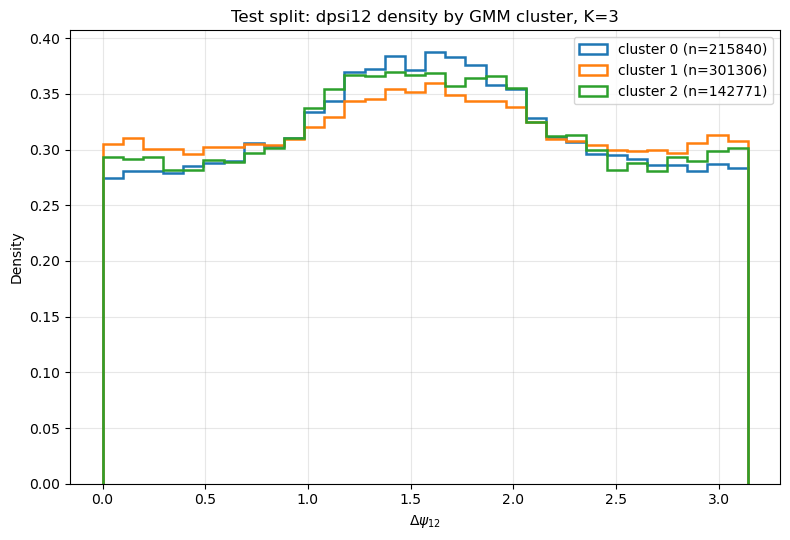

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_by_cluster_K4.png


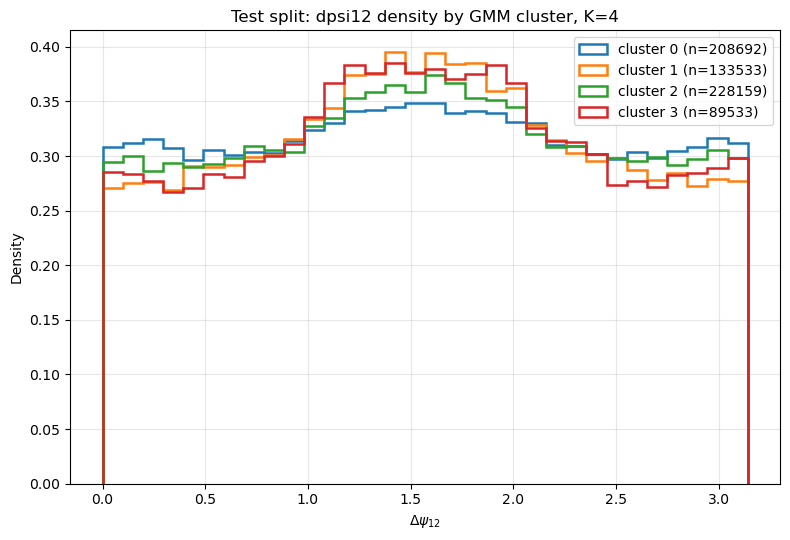

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_by_cluster_K5.png


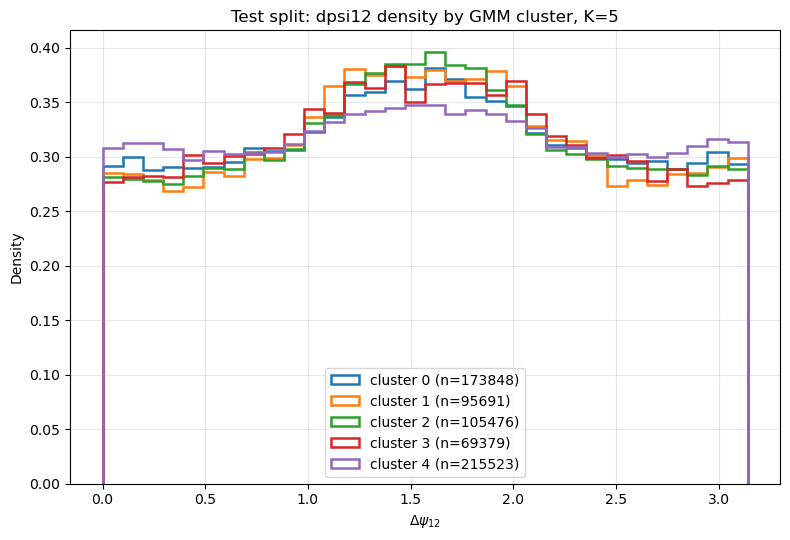

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_by_cluster_K6.png


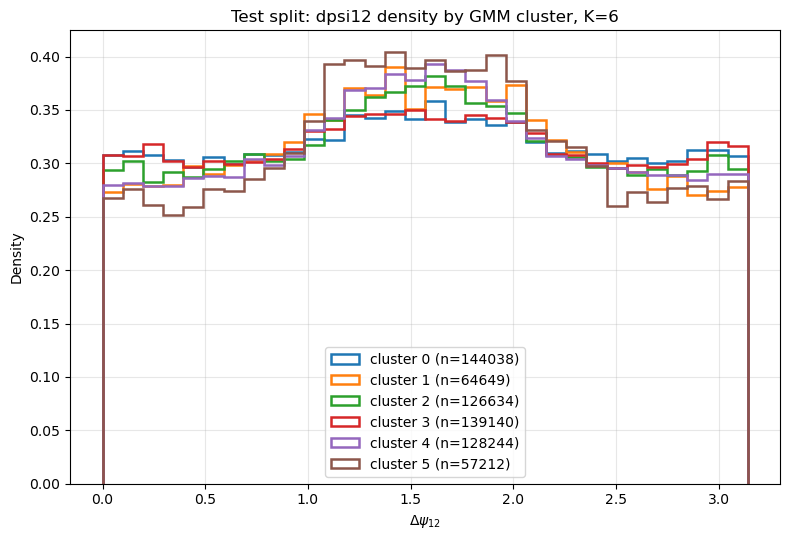

In [14]:

def plot_dpsi_density_by_cluster(
    df_eval,
    cluster_col="cluster",
    dpsi_col=DPSI_COL,
    title="dpsi12 density by cluster",
    bins=32,
    range_=(0, np.pi),
    save_path=None,
):
    plt.figure(figsize=(8, 5.5))

    for c in sorted(df_eval[cluster_col].unique()):
        dpsi = df_eval.loc[df_eval[cluster_col] == c, dpsi_col].dropna().to_numpy()
        plt.hist(
            dpsi,
            bins=bins,
            range=range_,
            density=True,
            histtype="step",
            linewidth=1.8,
            label=f"cluster {c} (n={len(dpsi)})",
        )

    plt.xlabel(r"$\Delta\psi_{12}$")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        print("Saved:", save_path)

    plt.show()


for k in K_VALUES:
    res = results[k]
    df_test_k = attach_cluster_info(df_test, res["cluster_test"], res["proba_test"])
    plot_dpsi_density_by_cluster(
        df_test_k,
        title=f"Test split: dpsi12 density by GMM cluster, K={k}",
        save_path=OUTPUT_DIR / f"dpsi12_density_by_cluster_K{k}.png",
    )


## 9. Plot `dpsi12` density for every individual cluster

This section makes one separate plot per cluster, including the fitted `a + b cos(2 dpsi12)` curve.

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K3_cluster0.png


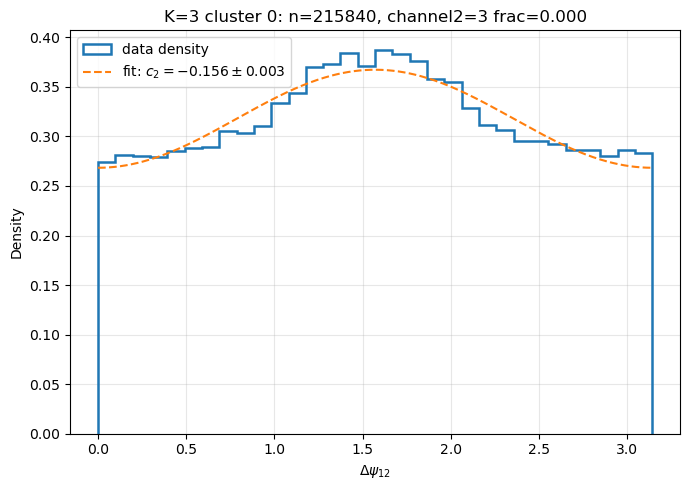

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K3_cluster1.png


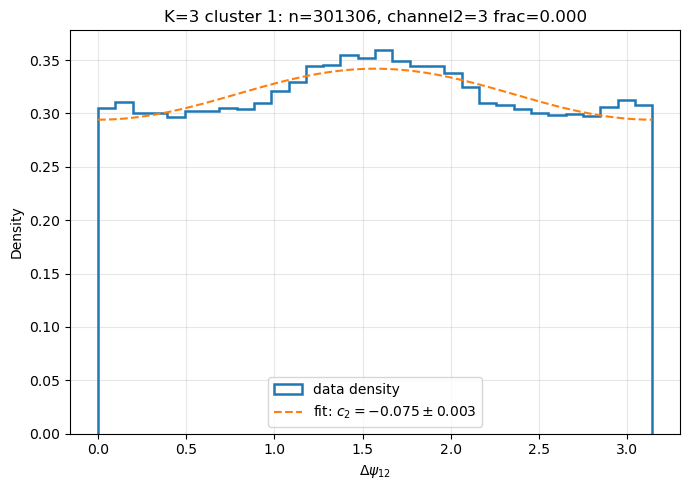

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K3_cluster2.png


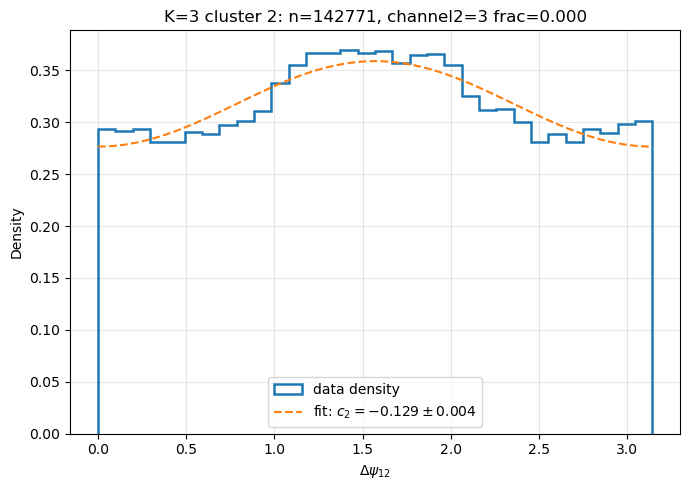

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K4_cluster0.png


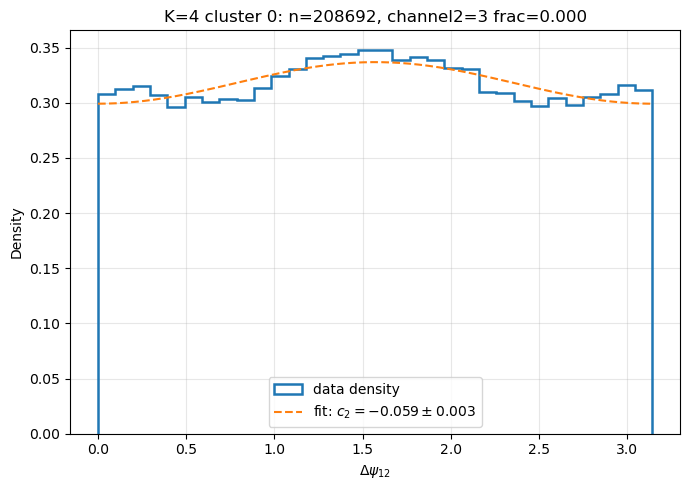

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K4_cluster1.png


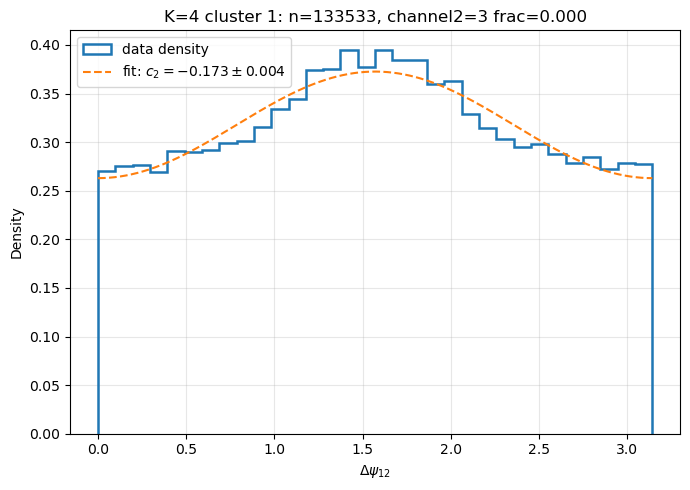

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K4_cluster2.png


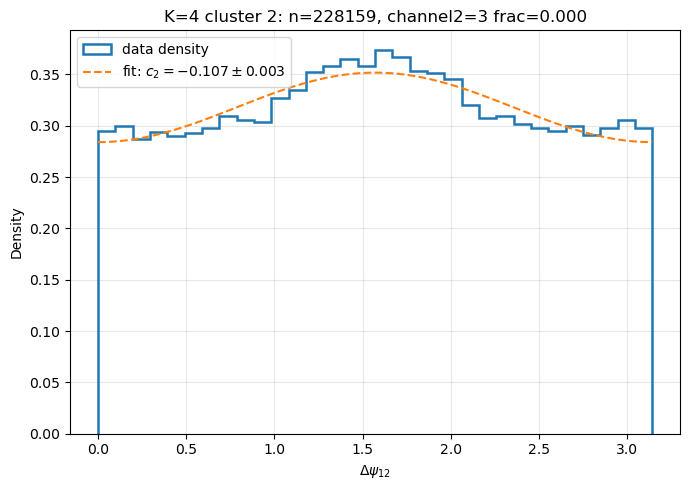

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K4_cluster3.png


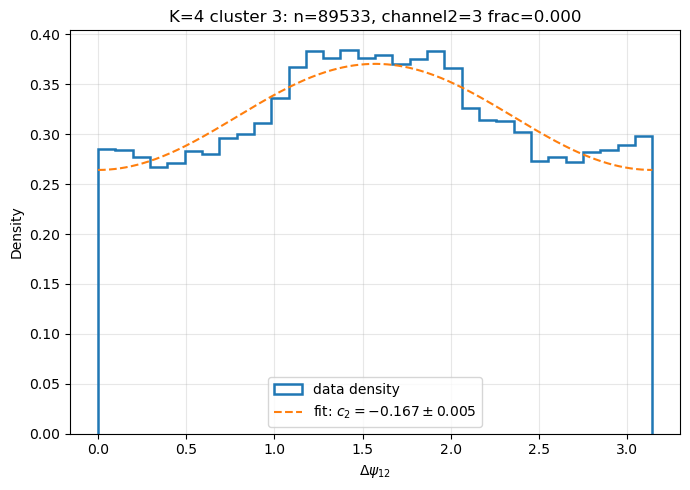

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K5_cluster0.png


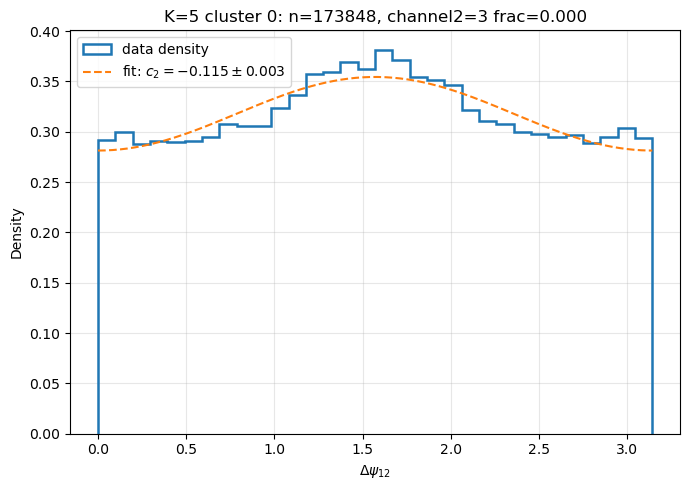

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K5_cluster1.png


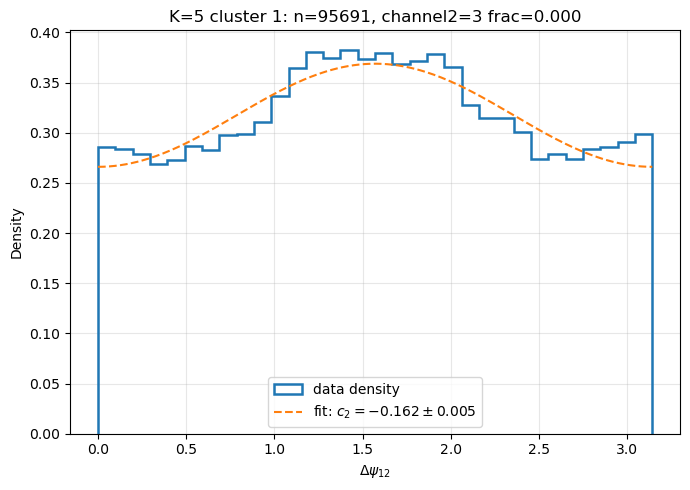

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K5_cluster2.png


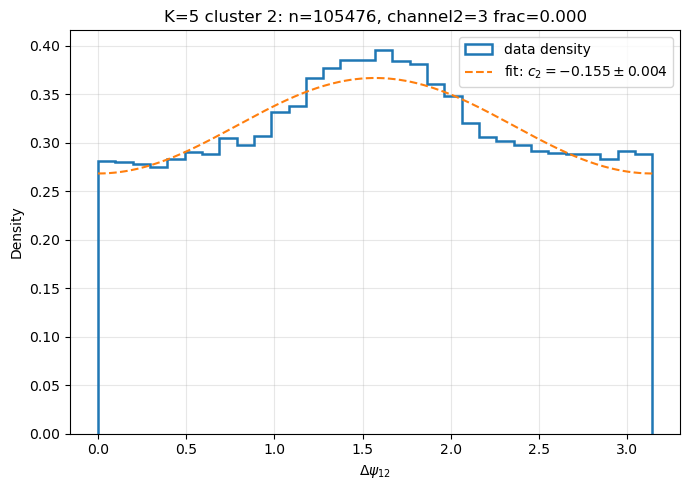

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K5_cluster3.png


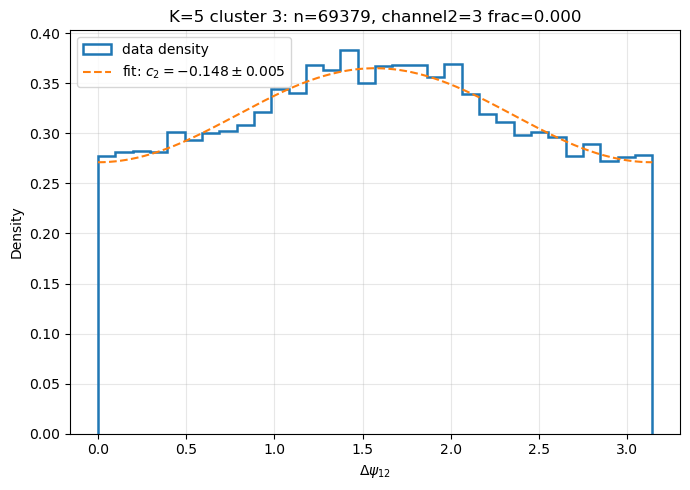

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K5_cluster4.png


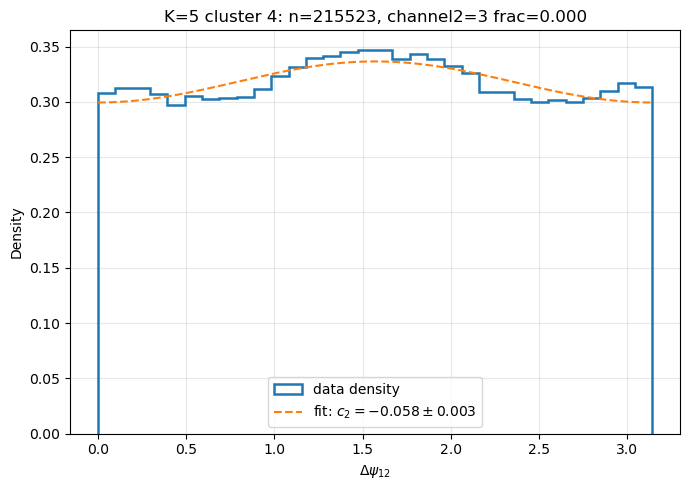

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K6_cluster0.png


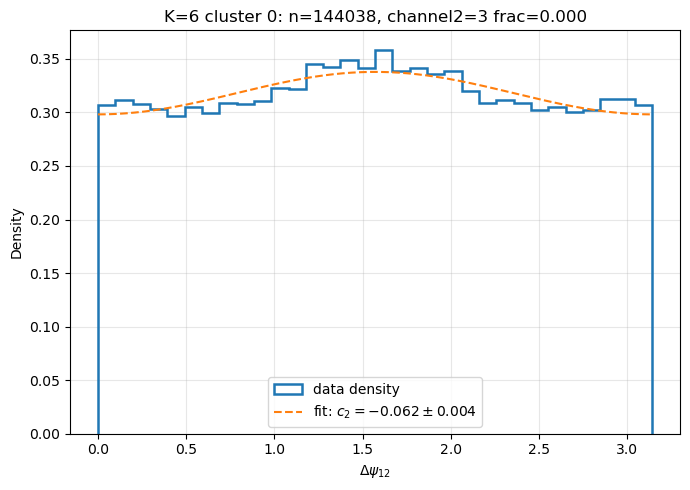

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K6_cluster1.png


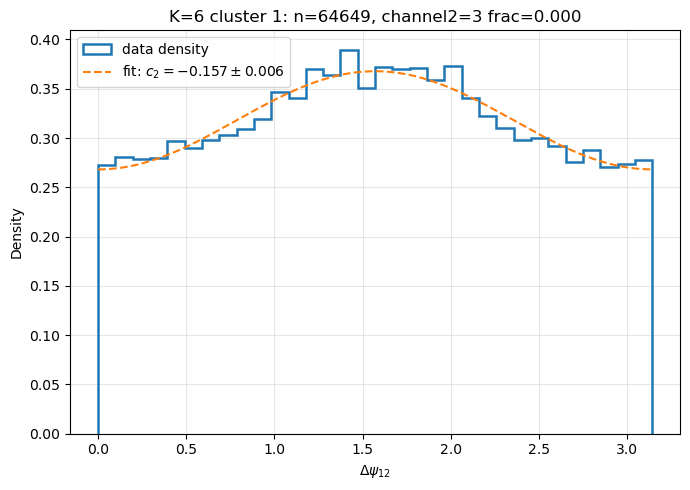

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K6_cluster2.png


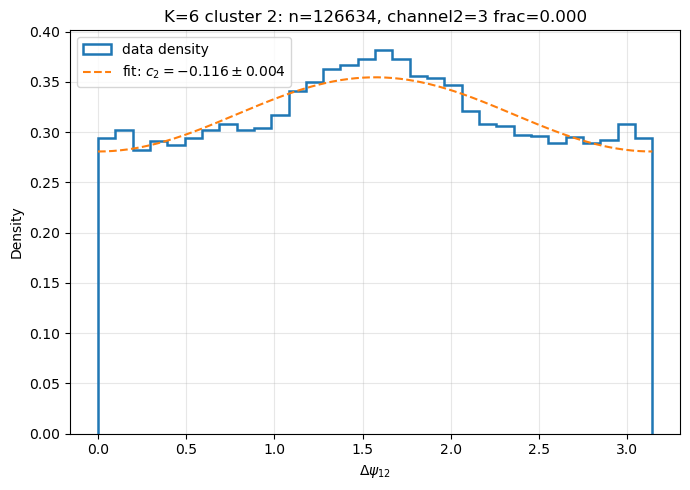

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K6_cluster3.png


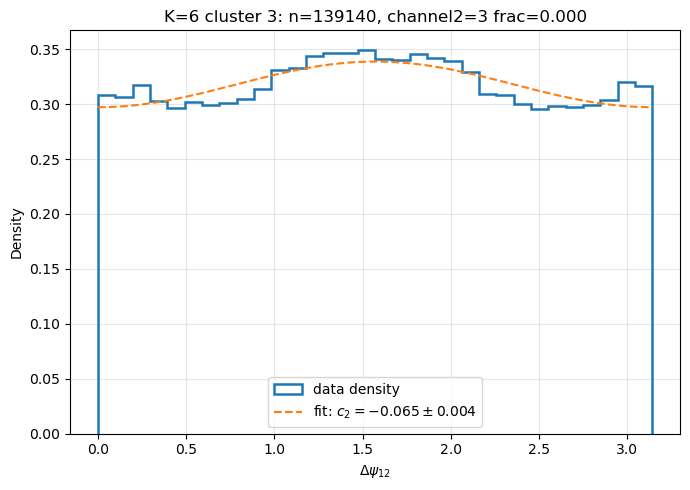

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K6_cluster4.png


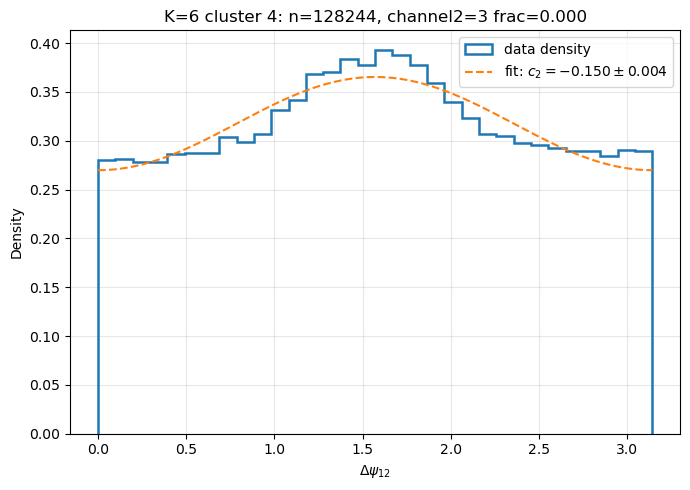

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_fit_K6_cluster5.png


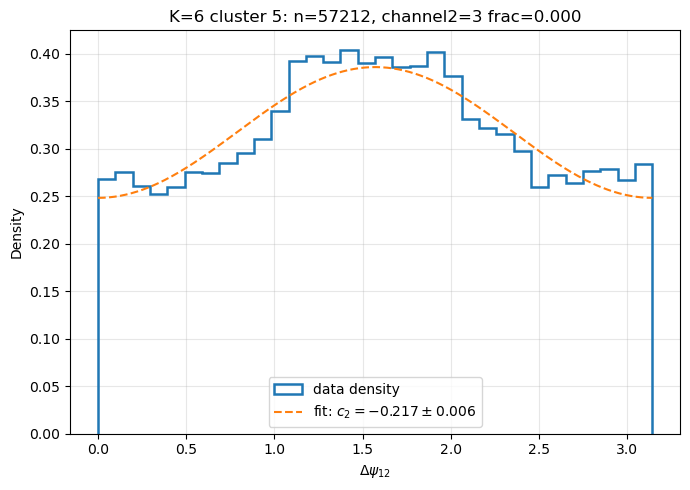

In [15]:

def plot_individual_cluster_dpsi_with_fit(
    df_eval,
    cluster_value,
    cluster_col="cluster",
    dpsi_col=DPSI_COL,
    bins=32,
    range_=(0, np.pi),
    title_prefix="",
    save_path=None,
):
    mask = df_eval[cluster_col] == cluster_value
    dpsi = df_eval.loc[mask, dpsi_col].dropna().to_numpy()

    # Histogram density for visualization.
    counts_density, edges = np.histogram(dpsi, bins=bins, range=range_, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    width = edges[1] - edges[0]

    fit_counts = fit_cos2(dpsi, bins=bins, range_=range_)

    plt.figure(figsize=(7, 5))
    plt.hist(
        dpsi,
        bins=bins,
        range=range_,
        density=True,
        histtype="step",
        linewidth=1.8,
        label="data density",
    )

    # Convert count-level fit to density-level curve.
    x = np.linspace(range_[0], range_[1], 300)
    if np.isfinite(fit_counts["a"]):
        total_counts = len(dpsi)
        y_counts = cos2_model(x, fit_counts["a"], fit_counts["b"])
        y_density = y_counts / (total_counts * width)
        plt.plot(
            x,
            y_density,
            linestyle="--",
            label=rf"fit: $c_2={fit_counts['c2']:.3f}\pm{fit_counts['c2_err']:.3f}$",
        )

    ch3_frac = np.mean(df_eval.loc[mask, TARGET] == 3)

    plt.xlabel(r"$\Delta\psi_{12}$")
    plt.ylabel("Density")
    plt.title(
        f"{title_prefix} cluster {cluster_value}: "
        f"n={len(dpsi)}, channel2=3 frac={ch3_frac:.3f}"
    )
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        print("Saved:", save_path)

    plt.show()


for k in K_VALUES:
    res = results[k]
    df_test_k = attach_cluster_info(df_test, res["cluster_test"], res["proba_test"])
    for cluster_id in sorted(df_test_k["cluster"].unique()):
        plot_individual_cluster_dpsi_with_fit(
            df_test_k,
            cluster_id,
            title_prefix=f"K={k}",
            save_path=OUTPUT_DIR / f"dpsi12_density_fit_K{k}_cluster{cluster_id}.png",
        )


## 10. Default K = 4: choose positive-c2 cluster core

This section proposes a gg-like candidate cluster using `K = 4` by selecting the cluster with the largest positive fitted `c2` on the validation split. Then it studies cluster-core cuts on the test split:

```python
cluster_probability > 0.7
```

You can override `GG_CLUSTER_ID` manually after inspecting the plots.

In [16]:
def choose_positive_c2_cluster_from_validation(k=DEFAULT_K, min_frac=0.03):
    """Choose cluster using validation split.

    Preference:
    1. positive c2,
    2. enough statistics,
    3. largest c2 significance,
    4. then largest c2.
    """
    res = results[k]
    df_val_k = attach_cluster_info(df_val, res["cluster_val"], res["proba_val"])
    table = cluster_cos2_table(df_val_k)

    display(table)

    if len(table) == 0:
        raise RuntimeError("No valid clusters found in c2 table.")

    table = table.copy()
    table["abs_frac"] = table["n"] / len(df_val_k)

    candidates = table[
        (table["c2"] > 0)
        & (table["abs_frac"] >= min_frac)
    ].copy()

    if len(candidates) == 0:
        print("No positive-c2 cluster with enough statistics. Choosing largest c2 anyway.")
        chosen = table.sort_values("c2", ascending=False).iloc[0]
    else:
        chosen = candidates.sort_values(
            ["c2_significance", "c2"],
            ascending=False
        ).iloc[0]

    print("Chosen cluster:")
    display(chosen.to_frame().T)

    return int(chosen["cluster"])


GG_CLUSTER_ID = choose_positive_c2_cluster_from_validation(DEFAULT_K, min_frac=0.03)
print(f"Default K={DEFAULT_K}; suggested positive-c2 cluster: {GG_CLUSTER_ID}")

,cluster,n,fraction,channel2_3_fraction,c2,c2_err,c2_significance
0,0,177005,0.315542,0.0,-2.620509e-09,0.408646,-6.412664e-09
1,1,113604,0.202519,0.0,-3.737570e-05,0.408248,-9.155146e-05
2,2,194667,0.347027,0.0,-4.531028e-05,0.408210,-1.109975e-04
3,3,75680,0.134913,0.0,-6.378655e-05,0.408322,-1.562165e-04


No positive-c2 cluster with enough statistics. Choosing largest c2 anyway.
Chosen cluster:


,cluster,n,fraction,channel2_3_fraction,c2,c2_err,c2_significance,abs_frac
0,0.0,177005.0,0.315542,0.0,-2.620509e-09,0.408646,-6.412664e-09,0.315542


Default K=4; suggested positive-c2 cluster: 0


In [17]:
res = results[DEFAULT_K]
df_test_default = attach_cluster_info(df_test, res["cluster_test"], res["proba_test"])
proba_test_default = res["proba_test"]
cluster_test_default = res["cluster_test"]

rows = []

for pcut in [0.5, 0.6, 0.7, 0.8, 0.9]:
    selected = (
        (cluster_test_default == GG_CLUSTER_ID)
        & (proba_test_default[:, GG_CLUSTER_ID] > pcut)
    )

    if selected.sum() < 50:
        print(f"pcut={pcut:.1f}: too few selected events ({selected.sum()})")
        continue

    fit = fit_cos2(df_test_default.loc[selected, DPSI_COL].to_numpy())

    rows.append({
        "K": DEFAULT_K,
        "cluster": GG_CLUSTER_ID,
        "probability_cut": pcut,
        "n_selected": int(selected.sum()),
        "selected_fraction": float(selected.mean()),
        "channel2_3_fraction": float(np.mean(df_test_default.loc[selected, TARGET] == 3)),
        "c2": fit["c2"],
        "c2_err": fit["c2_err"],
        "c2_significance": fit["significance"],
    })

core_scan_df = pd.DataFrame(rows)
display(core_scan_df)
core_scan_df.to_csv(
    OUTPUT_DIR / "gglike_candidate_cluster_core_scan.csv",
    index=False,
)

,K,cluster,probability_cut,n_selected,selected_fraction,channel2_3_fraction,c2,c2_err,c2_significance
0,4,0,0.5,208567,0.316050,0.0,6.937143e-10,0.408276,1.699130e-09
1,4,0,0.6,196619,0.297945,0.0,-2.614371e-07,0.408183,-6.404900e-07
2,4,0,0.7,183616,0.278241,0.0,-2.474539e-05,0.408279,-6.060895e-05
3,4,0,0.8,167274,0.253477,0.0,-1.363141e-05,0.408236,-3.339097e-05
4,4,0,0.9,141521,0.214453,0.0,-9.655487e-06,0.406945,-2.372676e-05


Saved: outputs_unsupervised_gmm_matched/dpsi12_density_K4_cluster0_core_p0.5.png


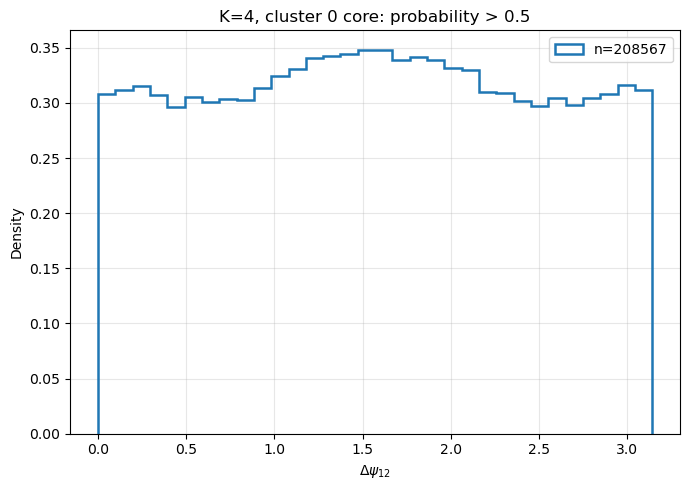

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_K4_cluster0_core_p0.6.png


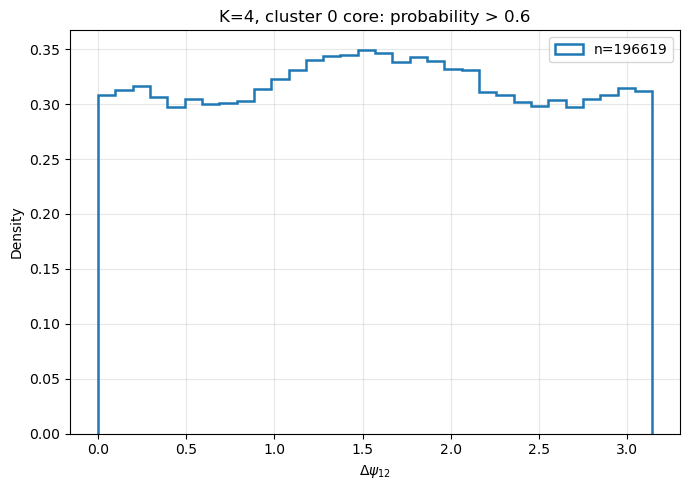

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_K4_cluster0_core_p0.7.png


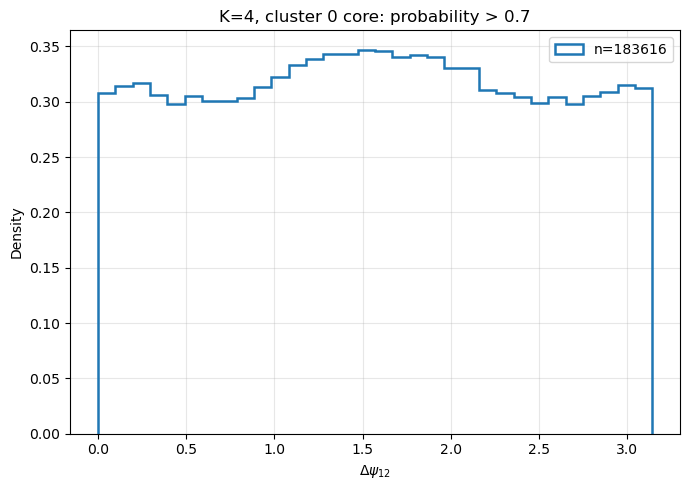

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_K4_cluster0_core_p0.8.png


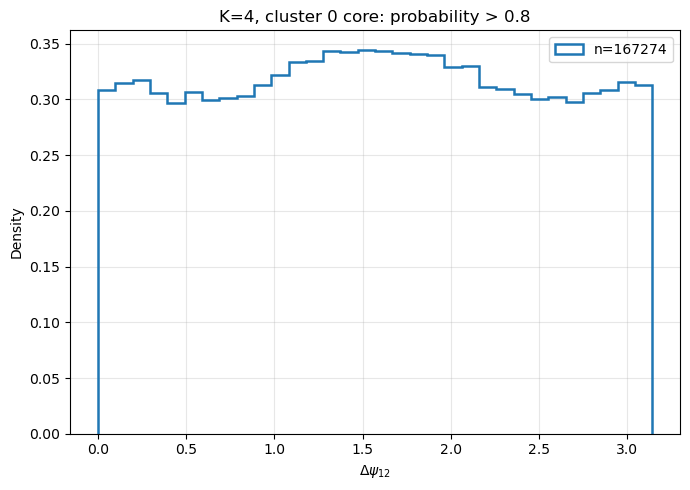

Saved: outputs_unsupervised_gmm_matched/dpsi12_density_K4_cluster0_core_p0.9.png


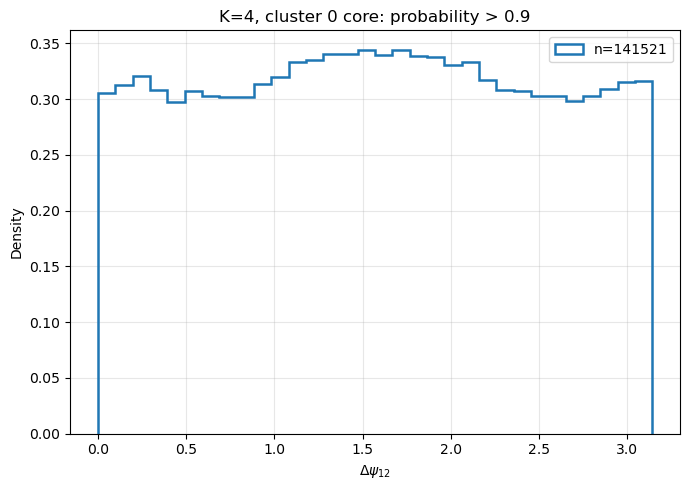

In [18]:

# Plot selected cluster cores for probability cuts.
for pcut in [0.5, 0.6, 0.7, 0.8, 0.9]:
    selected = (
        (cluster_test_default == GG_CLUSTER_ID)
        & (proba_test_default[:, GG_CLUSTER_ID] > pcut)
    )
    if selected.sum() < 50:
        continue

    tmp = df_test_default.loc[selected].copy()
    tmp["selected_core"] = f"cluster {GG_CLUSTER_ID}, p>{pcut}"

    plt.figure(figsize=(7, 5))
    plt.hist(
        tmp[DPSI_COL].dropna().to_numpy(),
        bins=32,
        range=(0, np.pi),
        density=True,
        histtype="step",
        linewidth=1.8,
        label=f"n={len(tmp)}",
    )
    plt.xlabel(r"$\Delta\psi_{12}$")
    plt.ylabel("Density")
    plt.title(f"K={DEFAULT_K}, cluster {GG_CLUSTER_ID} core: probability > {pcut}")
    plt.legend()
    plt.tight_layout()
    out = OUTPUT_DIR / f"dpsi12_density_K{DEFAULT_K}_cluster{GG_CLUSTER_ID}_core_p{pcut:.1f}.png"
    plt.savefig(out, dpi=150)
    print("Saved:", out)
    plt.show()


## 11. Optional 2D PCA visualization

This plot is only for visualization of the GMM clusters. It is not used for training or validation.

Saved: outputs_unsupervised_gmm_matched/pca_clusters_K3.png


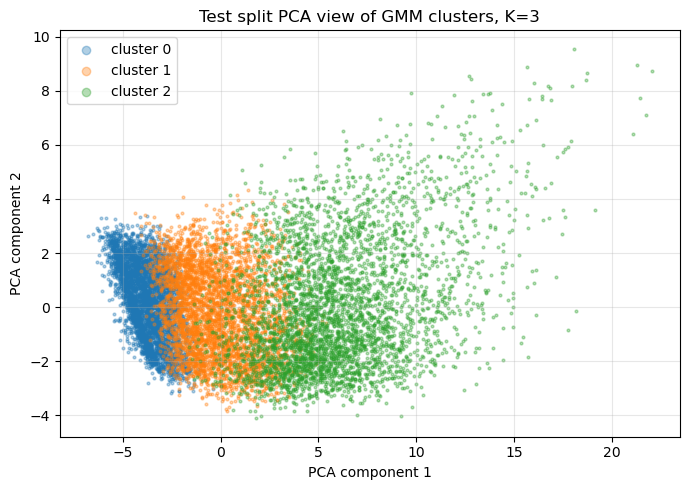

Saved: outputs_unsupervised_gmm_matched/pca_clusters_K4.png


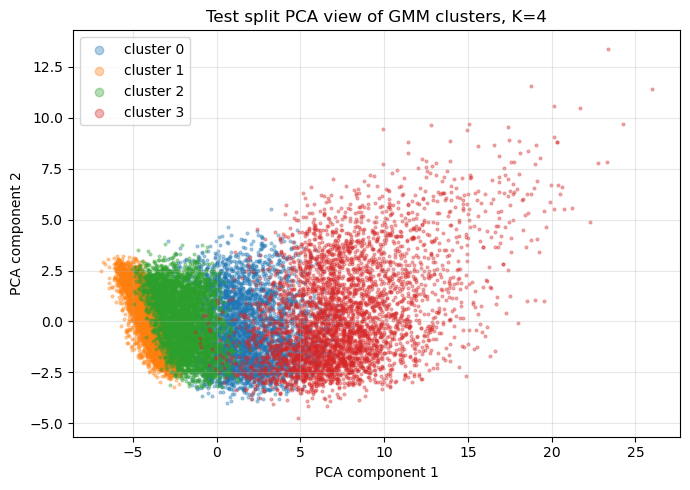

Saved: outputs_unsupervised_gmm_matched/pca_clusters_K5.png


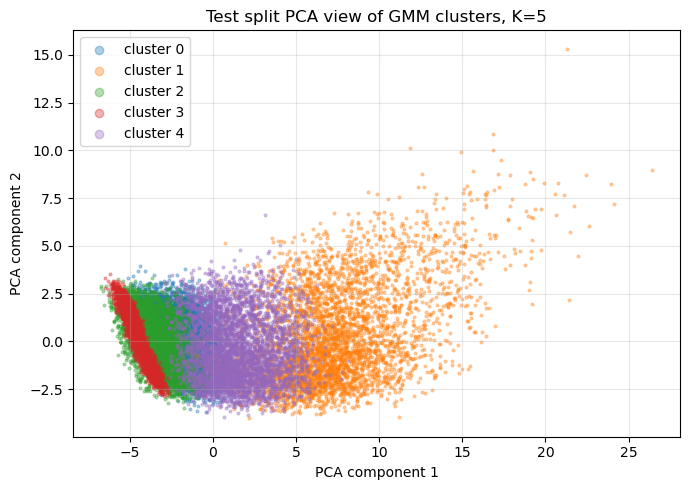

Saved: outputs_unsupervised_gmm_matched/pca_clusters_K6.png


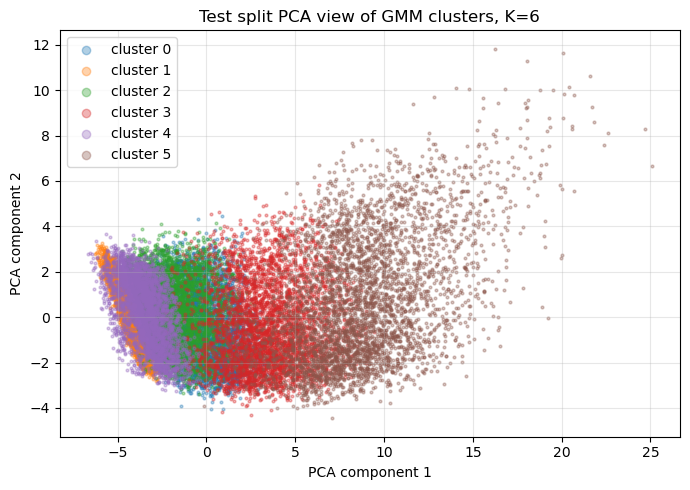

In [19]:

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_test_pca = pca.fit_transform(X_test_pp)

for k in K_VALUES:
    cluster = results[k]["cluster_test"]
    plt.figure(figsize=(7, 5))
    for c in sorted(np.unique(cluster)):
        mask = cluster == c
        # subsample for speed/visibility
        idx = np.where(mask)[0]
        if len(idx) > 4000:
            rng = np.random.default_rng(RANDOM_STATE)
            idx = rng.choice(idx, size=4000, replace=False)
        plt.scatter(X_test_pca[idx, 0], X_test_pca[idx, 1], s=4, alpha=0.35, label=f"cluster {c}")
    plt.xlabel("PCA component 1")
    plt.ylabel("PCA component 2")
    plt.title(f"Test split PCA view of GMM clusters, K={k}")
    plt.legend(markerscale=3)
    plt.tight_layout()
    out = OUTPUT_DIR / f"pca_clusters_K{k}.png"
    plt.savefig(out, dpi=150)
    print("Saved:", out)
    plt.show()


In [20]:
fit = fit_cos2(df_feat["dpsi12"].to_numpy(), range_=(0, np.pi))
print(fit)

{'a': 183049.34392445598, 'b': -20925.238498391336, 'c2': -0.11431474186013543, 'c2_err': 0.0006837064649468081, 'significance': -167.1985679834533, 'centers': array([0.06544985, 0.19634954, 0.32724923, 0.45814893, 0.58904862,
       0.71994832, 0.85084801, 0.9817477 , 1.1126474 , 1.24354709,
       1.37444679, 1.50534648, 1.63624617, 1.76714587, 1.89804556,
       2.02894526, 2.15984495, 2.29074464, 2.42164434, 2.55254403,
       2.68344372, 2.81434342, 2.94524311, 3.07614281]), 'counts': array([169846, 170007, 167745, 167885, 170095, 171870, 176736, 185321,
       195749, 205112, 209063, 210178, 210322, 208185, 204349, 196156,
       184820, 176937, 172556, 168788, 167182, 168524, 169566, 170991]), 'edges': array([0.        , 0.13089969, 0.26179939, 0.39269908, 0.52359878,
       0.65449847, 0.78539816, 0.91629786, 1.04719755, 1.17809725,
       1.30899694, 1.43989663, 1.57079633, 1.70169602, 1.83259571,
       1.96349541, 2.0943951 , 2.2252948 , 2.35619449, 2.48709418,
       2.6179